# PCA Dislocation on Swap Spreads (MMSS / Spreadover)

Applies the PCA dislocation framework directly to swap spread **changes**:

1. Run rolling PCA on daily spread changes across the benchmark tenor panel (2Y–30Y)
2. Reconstruct each tenor's 'fair' spread change from the top-k PCs
3. Cumulate the out-of-sample residuals (the idiosyncratic component)
4. Model cumulative residuals as an OU process → z-score
5. Trade dislocations via outright swap spread trades (bond + matched-maturity swap per leg)

**Spread convention:** spread = swap rate − treasury yield (negative in US).
- **Buy spread (pay spread):** buy bonds + pay fixed swaps → profit when spread goes UP (narrows, less negative)
- **Sell spread (receive spread):** sell bonds + receive fixed swaps → profit when spread goes DOWN (widens, more negative)

**MMSS vs Spreadover:** When `use_mmss=True`, the swap leg tenor is set to `CT{N}` which matches the swap maturity to the OTR bond maturity. When `False`, uses headline `{N}Y` tenor.

In [40]:
%load_ext autoreload
%autoreload 2

import datetime, sys, os, time, itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import QuantLib as ql

plt.style.use('ggplot')
pylab.rcParams.update({
    'legend.fontsize': 'x-large', 'figure.figsize': (18, 8),
    'axes.labelsize': 'x-large', 'axes.titlesize': 'x-large',
    'xtick.labelsize': 'large', 'ytick.labelsize': 'large',
})

sys.path.append('../../')

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements
from BT.query_tearsheet import QueryBacktestTearSheet

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue
from Query.FixedRateBonds.carry_roll import load_us_treasury_gc_fixing_pct
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

from BT.signals.tfp_swap_spread import (
    BENCHMARK_TENORS, REGRESSION_TENORS, CT_MAP, build_tfp_history,
)
from BT.signals.irswap_pca_rv_scanner import IRSwapPCARVConfig, _rolling_pca_surface
from BT.signals.tfp_packages import _ou_params
from RVUtils.plt_timeseries import make_secondary_axis_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Config

In [41]:
cfg = dict(
    signal_start    = datetime.date(2020, 6, 1),
    bt_start        = datetime.date(2021, 6, 1),
    bt_end          = datetime.date(2026, 5, 14),

    # PCA
    pca_window      = 520,       # ~2yr rolling PCA
    pca_input       = 'changes', # PCA on daily spread changes (not levels)
    n_components    = 3,         # top 3 PCs (level/slope/curvature)

    # Z-score on cumulative residuals
    zscore_window   = 260,       # ~1yr decoupled lookback for z-score
    z_entry         = 1.5,       # entry threshold
    z_exit          = 0.25,      # exit near zero (mean-reversion target)
    max_hold        = 60,        # max holding period

    # Trade universe
    tenors          = ['2Y', '3Y', '5Y', '7Y', '10Y', '30Y'],

    # Spread type: True = matched-maturity (CT prefix), False = headline spreadover
    use_mmss        = True,

    # Risk
    risk_bpv        = 100_000,
    unwind_fee_bps  = 0.5,
    specialness_bps = 10.0,

    # Data
    irs_source      = 'ERIS_EOD_LIVE-RL_BASIC',
    frb_source      = 'USTS_FEDINVEST_WSJ_LIVE-QL',
    cache_path      = os.path.abspath(os.path.join(
        os.getcwd(), '..', '..', 'BT', 'results', 'tfp_screener', 'tfp_history.parquet'
    )),
)

for k, v in cfg.items():
    print(f'  {k}: {v}')

  signal_start: 2020-06-01
  bt_start: 2021-06-01
  bt_end: 2026-05-14
  pca_window: 520
  pca_input: changes
  n_components: 3
  zscore_window: 260
  z_entry: 1.5
  z_exit: 0.25
  max_hold: 60
  tenors: ['2Y', '3Y', '5Y', '7Y', '10Y', '30Y']
  use_mmss: True
  risk_bpv: 100000
  unwind_fee_bps: 0.5
  specialness_bps: 10.0
  irs_source: ERIS_EOD_LIVE-RL_BASIC
  frb_source: USTS_FEDINVEST_WSJ_LIVE-QL
  cache_path: c:\Users\chris\clee\ARBS\BT\results\tfp_screener\tfp_history.parquet


## Load MMSS Panel

In [42]:
curve_mdp = IRSwapsMDP(source=cfg['irs_source'])
usts_mdp = FixedRateBondsMDP(source='USTS_FEDINVEST_WSJ_LIVE-RL')

history = build_tfp_history(
    start_date=cfg['signal_start'], end_date=cfg['bt_end'],
    curve_mdp=curve_mdp, usts_mdp=usts_mdp,
    cache_path=cfg['cache_path'], show_progress=True,
)

# Build MMSS panel: (date x tenor) from the cached TFP history
mmss_panel = pd.DataFrame({
    t: history[f'mmss_{t}'] for t in cfg['tenors'] if f'mmss_{t}' in history.columns
}).dropna()

print(f'MMSS panel: {mmss_panel.shape[0]} dates x {mmss_panel.shape[1]} tenors')
print(f'Tenors: {mmss_panel.columns.tolist()}')
print(f'Range: {mmss_panel.index.min()} to {mmss_panel.index.max()}')
mmss_panel.tail()

MMSS panel: 1475 dates x 6 tenors
Tenors: ['2Y', '3Y', '5Y', '7Y', '10Y', '30Y']
Range: 2020-06-22 00:00:00 to 2026-05-14 00:00:00


,2Y,3Y,5Y,7Y,10Y,30Y
date,,,,,,
2026-05-08,-16.704807,-20.820668,-28.513365,-35.191996,-41.404614,-71.652659
2026-05-11,-18.908454,-23.800253,-30.265469,-37.939666,-43.262718,-73.676693
2026-05-12,-16.915295,-20.919930,-28.263889,-36.921184,-41.864600,-73.023950
2026-05-13,-16.060925,-21.385833,-28.735127,-37.211077,-43.235861,-74.950783
2026-05-14,-17.256295,-21.987016,-28.745907,-36.778102,-41.789877,-73.329002


## Rolling PCA → Residuals → Z-scores

Uses the production `_rolling_pca_surface` engine from `irswap_pca_rv_scanner.py`.

In [43]:
pca_cfg = IRSwapPCARVConfig(
    pca_window_days=cfg['pca_window'],
    pca_input=cfg['pca_input'],
    n_components=cfg['n_components'],
    zscore_lookback_days=cfg['zscore_window'],
)

t0 = time.time()
residuals, zscores, var_exp, loadings_dict, reconstructed = _rolling_pca_surface(
    mmss_panel, pca_cfg,
)
print(f'PCA scan: {time.time()-t0:.1f}s')
print(f'Residuals non-NaN: {residuals.notna().sum().to_dict()}')
print(f'Z-scores non-NaN:  {zscores.notna().sum().to_dict()}')

# Variance explained by top 3 PCs
ve_recent = var_exp.dropna().tail(60)
if not ve_recent.empty:
    print(f'\nVariance explained (last 60d avg): {ve_recent.mean().to_dict()}')

PCA scan: 1.5s
Residuals non-NaN: {'2Y': 955, '3Y': 955, '5Y': 955, '7Y': 955, '10Y': 955, '30Y': 955}
Z-scores non-NaN:  {'2Y': 695, '3Y': 695, '5Y': 695, '7Y': 695, '10Y': 695, '30Y': 695}

Variance explained (last 60d avg): {'PC1': 0.7700136031605288, 'PC2': 0.13863463384371438, 'PC3': 0.04541106645899742}


## Cumulative Residuals + OU Analytics

In [44]:
# Cumulate residuals — the OU process lives on the cumulated series
cum_residuals = residuals.cumsum()

# OU diagnostics per tenor
print(f'{"Tenor":>6s}  {"OU mu":>8s}  {"OU HL":>7s}  {"OU theta":>9s}  {"OU sigma":>9s}')
print('-' * 50)
for t in cfg['tenors']:
    if t not in cum_residuals.columns:
        continue
    s = cum_residuals[t].dropna()
    if len(s) < 100:
        continue
    ou = _ou_params(s.iloc[-cfg['pca_window']:])
    print(f'{t:>6s}  {ou["mu"]:>8.2f}  {ou["half_life"]:>7.0f}d  {ou["theta"]:>9.3f}  {ou["sigma"]:>9.3f}')

 Tenor     OU mu    OU HL   OU theta   OU sigma
--------------------------------------------------
    2Y     -4.67        3d      0.219      0.171
    3Y      6.48        2d      0.290      0.455
    5Y      5.85        2d      0.426      0.406
    7Y     -2.11        5d      0.138      0.407
   10Y    -10.08       35d      0.020      0.278
   30Y      3.94       10d      0.067      0.229


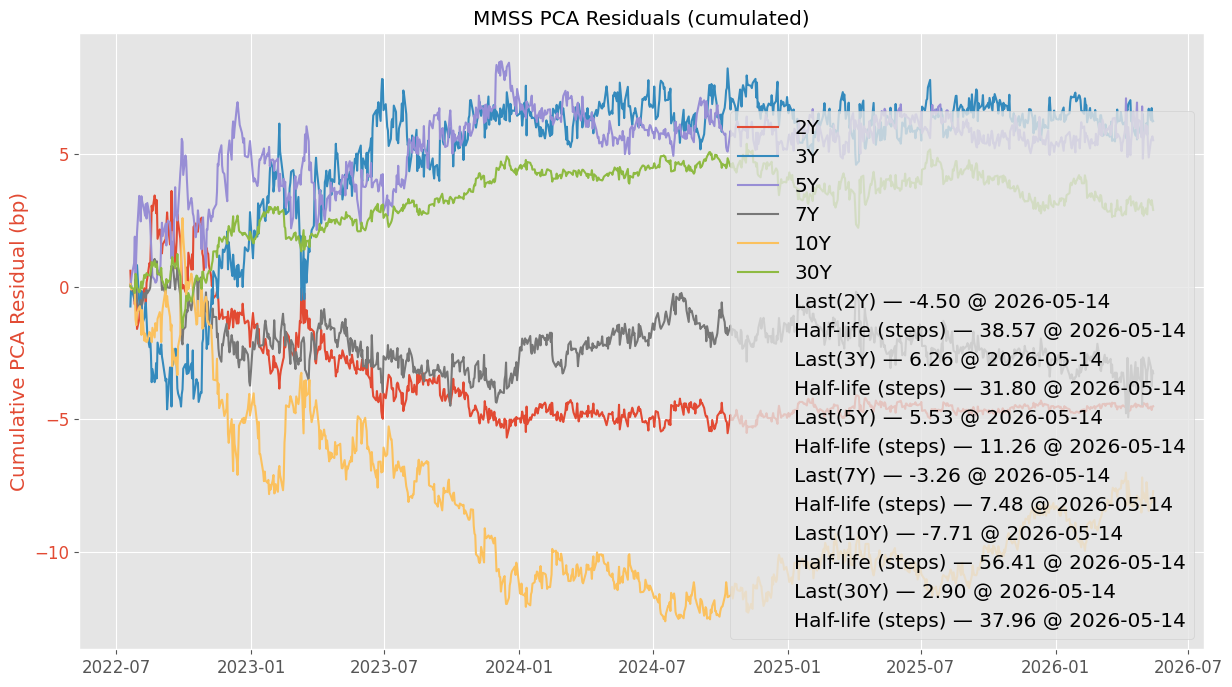

In [45]:
# Plot cumulative residuals
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Cumulative PCA Residual (bp)', title='MMSS PCA Residuals (cumulated)',
)
for t in cfg['tenors']:
    if t in cum_residuals.columns:
        s = cum_residuals[t].loc[cfg['bt_start']:cfg['bt_end']]
        plot(s.rename(t), which='left', indicators=[
            {'kind': 'last', 'hide': True},
            {'kind': 'half_life', 'hide': True},
        ])
legend(show_date=True)
plt.show()

## Z-score Surface & Signal Generation

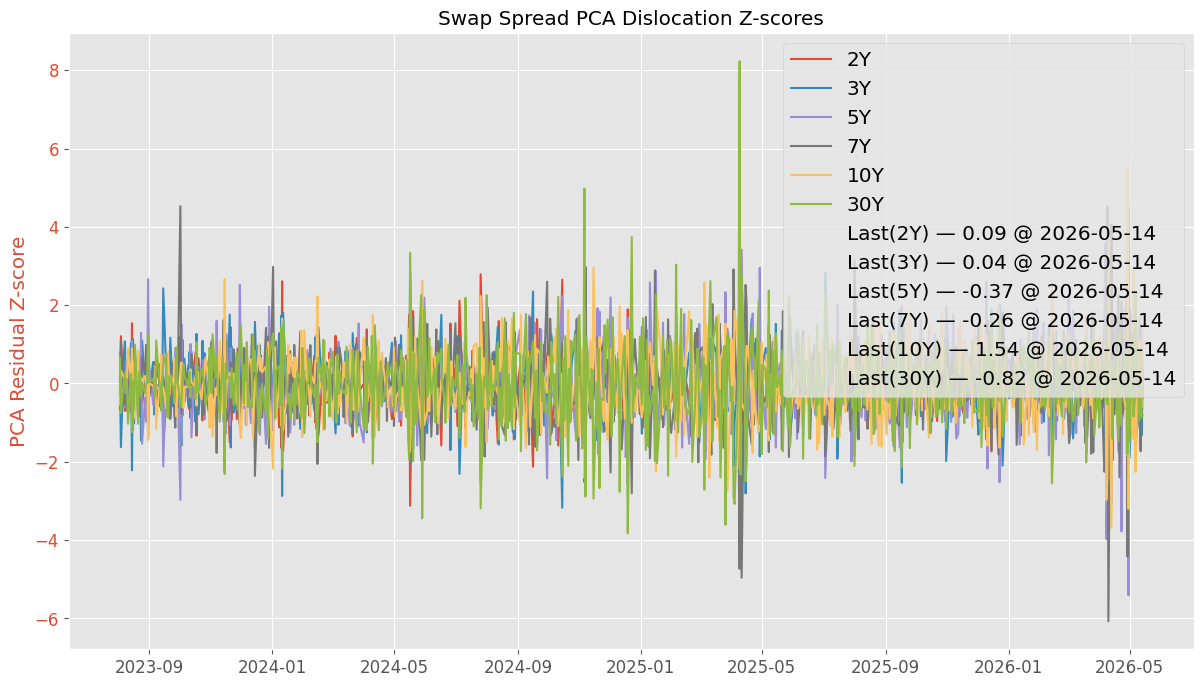

Current PCA dislocation z-scores:
  spread = swap rate - treasury yield
  z < 0 → spread cheap (below PCA fair value) → buy spread (buy bonds + pay swaps)
  z > 0 → spread rich  (above PCA fair value) → sell spread (sell bonds + receive swaps)

    2Y: z = +0.09  neutral
    3Y: z = +0.04  neutral
    5Y: z = -0.37  neutral
    7Y: z = -0.26  neutral
   10Y: z = +1.54  RICH → SELL SPREAD (sell bonds + receive swaps)
   30Y: z = -0.82  neutral


In [46]:
# Plot z-score surface
z_bt = zscores.loc[cfg['bt_start']:cfg['bt_end']]

plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='PCA Residual Z-score', title='Swap Spread PCA Dislocation Z-scores',
)
for t in cfg['tenors']:
    if t in z_bt.columns:
        plot(z_bt[t].rename(t), which='left', indicators=[{'kind': 'last', 'hide': True}])
legend(show_date=True)
plt.show()

# Current snapshot
latest_z = zscores.dropna(how='all').iloc[-1]
print('Current PCA dislocation z-scores:')
print('  spread = swap rate - treasury yield')
print('  z < 0 → spread cheap (below PCA fair value) → buy spread (buy bonds + pay swaps)')
print('  z > 0 → spread rich  (above PCA fair value) → sell spread (sell bonds + receive swaps)')
print()
for t in cfg['tenors']:
    if t in latest_z.index and pd.notna(latest_z[t]):
        z_val = latest_z[t]
        if z_val < -cfg['z_entry']:
            tag = 'CHEAP → BUY SPREAD (buy bonds + pay swaps)'
        elif z_val > cfg['z_entry']:
            tag = 'RICH → SELL SPREAD (sell bonds + receive swaps)'
        else:
            tag = 'neutral'
        print(f'  {t:>4s}: z = {z_val:+.2f}  {tag}')

In [47]:
# Generate entry/exit signals per tenor
# Signal convention:
#   +1 = BUY SPREAD (buy bonds + pay swaps) → want spread to go UP (less negative)
#        triggered when z < -z_entry (spread is cheap vs PCA fair value)
#   -1 = SELL SPREAD (sell bonds + receive swaps) → want spread to go DOWN (more negative)
#        triggered when z > +z_entry (spread is rich vs PCA fair value)

def generate_pca_signals(zscores, z_entry, z_exit, max_hold):
    signals = pd.DataFrame(0, index=zscores.index, columns=zscores.columns, dtype=np.int8)
    for t in zscores.columns:
        z = zscores[t].values
        sig = np.zeros(len(z), dtype=np.int8)
        pos = 0; hold = 0
        for i in range(len(z)):
            v = z[i]
            if np.isnan(v):
                sig[i] = 0; pos = 0; hold = 0; continue
            if pos == 0:
                if v < -z_entry:   pos = +1; hold = 0  # cheap → buy spread
                elif v > z_entry:  pos = -1; hold = 0  # rich  → sell spread
            else:
                hold += 1
                exit_now = hold >= max_hold
                if not exit_now:
                    if pos == +1 and v >= -z_exit: exit_now = True   # bought spread, z reverted up
                    elif pos == -1 and v <= z_exit: exit_now = True  # sold spread, z reverted down
                if exit_now: pos = 0; hold = 0
            sig[i] = pos
        signals[t] = sig
    return signals

pca_signals = generate_pca_signals(zscores, cfg['z_entry'], cfg['z_exit'], cfg['max_hold'])

for t in cfg['tenors']:
    if t in pca_signals.columns:
        sig_bt = pca_signals[t].loc[cfg['bt_start']:cfg['bt_end']]
        n_buy = ((sig_bt == 1) & (sig_bt.shift(1).fillna(0) != 1)).sum()
        n_sell = ((sig_bt == -1) & (sig_bt.shift(1).fillna(0) != -1)).sum()
        print(f'  {t}: {n_buy + n_sell} trades ({n_buy} buy spread, {n_sell} sell spread)')

  2Y: 30 trades (15 buy spread, 15 sell spread)
  3Y: 50 trades (25 buy spread, 25 sell spread)
  5Y: 66 trades (27 buy spread, 39 sell spread)
  7Y: 58 trades (32 buy spread, 26 sell spread)
  10Y: 53 trades (24 buy spread, 29 sell spread)
  30Y: 64 trades (35 buy spread, 29 sell spread)


## Vectorized P&L Preview (fast screening before full QDB)

In [48]:
h_bt = mmss_panel.loc[cfg['bt_start']:cfg['bt_end']]
preview = []
equity_curves = {}

for t in cfg['tenors']:
    if t not in pca_signals.columns or t not in h_bt.columns:
        continue
    sig = pca_signals[t].loc[cfg['bt_start']:cfg['bt_end']].reindex(h_bt.index).fillna(0)
    # sig=+1 (buy spread) profits when spread goes UP (MMSS increases / less negative)
    # sig=-1 (sell spread) profits when spread goes DOWN (MMSS decreases / more negative)
    # P&L = signal × Δ(spread)
    daily = sig.shift(1) * h_bt[t].diff()
    daily = daily.fillna(0)
    cum = daily.cumsum()
    equity_curves[t] = cum

    sh = daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else 0
    mdd = (cum - cum.cummax()).min()
    n_trades = ((sig != 0) & (sig.shift(1).fillna(0) == 0)).sum()
    
    cr = cum_residuals[t].loc[cfg['bt_start']:cfg['bt_end']].dropna()
    ou = _ou_params(cr) if len(cr) > 60 else {'half_life': np.nan}

    preview.append(dict(
        Tenor=t, Sharpe=round(sh, 3), Total_bp=round(cum.iloc[-1], 1),
        MaxDD_bp=round(mdd, 1), Trades=int(n_trades),
        OU_HL=round(ou['half_life'], 0) if np.isfinite(ou.get('half_life', np.nan)) else np.nan,
    ))

preview_df = pd.DataFrame(preview).sort_values('Sharpe', ascending=False)
preview_df

,Tenor,Sharpe,Total_bp,MaxDD_bp,Trades,OU_HL
0,2Y,1.063,22.5,-6.9,30,39.0
3,7Y,0.728,24.5,-9.0,58,7.0
4,10Y,0.460,16.8,-10.1,53,56.0
1,3Y,0.216,6.3,-9.2,50,32.0
2,5Y,-0.024,-0.8,-15.0,66,11.0
5,30Y,-0.433,-19.5,-22.2,64,38.0


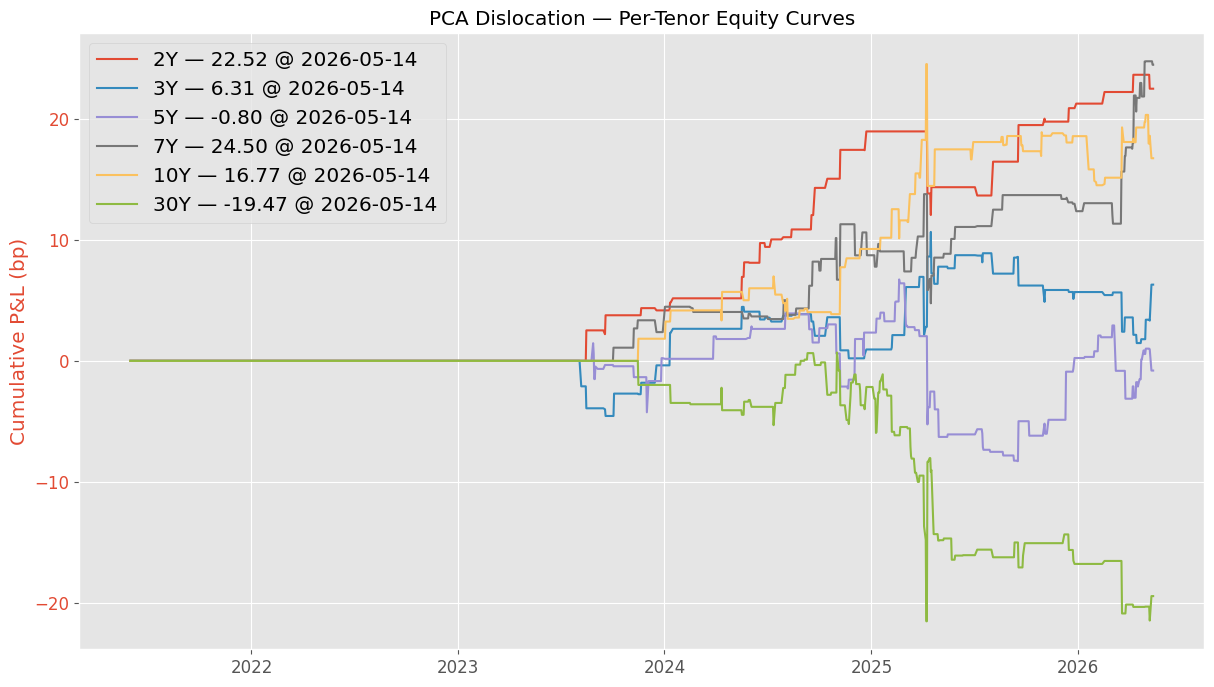

In [49]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Cumulative P&L (bp)', title='PCA Dislocation — Per-Tenor Equity Curves',
)
for t, eq in equity_curves.items():
    # plot(eq.rename(t), which='left', indicators=[{'kind': 'last', 'hide': True}])
    plot(eq.rename(t), which='left')
legend(show_date=True)
plt.show()

## Extract Entry/Exit Events

In [50]:
# Convert PCA signals → entry/exit events with datetime.date (required by DateTriggerRequirements)
TRADE_TENORS = preview_df[preview_df['Sharpe'] > 0]['Tenor'].tolist()
print(f'Trading tenors (Sharpe > 0): {TRADE_TENORS}')

def extract_pca_events(sig_series, tenor, bt_start, bt_end):
    sig = sig_series.loc[bt_start:bt_end]
    dates = [d.date() if hasattr(d, 'date') else d for d in sig.index]
    vals = sig.values
    events = []
    prev = 0; entry_date = None; direction = 0
    for i in range(len(vals)):
        cur = int(vals[i])
        if prev == 0 and cur != 0:
            entry_date = dates[i]; direction = cur
        elif prev != 0 and cur == 0:
            events.append(dict(
                entry_date=entry_date, exit_date=dates[i],
                direction=direction, tenor=tenor,
                tag=f'pca-{tenor}-{entry_date}',
            ))
            entry_date = None; direction = 0
        elif prev != 0 and cur != 0 and cur != prev:
            events.append(dict(
                entry_date=entry_date, exit_date=dates[i],
                direction=direction, tenor=tenor,
                tag=f'pca-{tenor}-{entry_date}',
            ))
            entry_date = dates[i]; direction = cur
        prev = cur
    if entry_date is not None:
        events.append(dict(
            entry_date=entry_date, exit_date=dates[-1],
            direction=direction, tenor=tenor,
            tag=f'pca-{tenor}-{entry_date}',
        ))
    return events

all_events = []
for tenor in TRADE_TENORS:
    if tenor not in pca_signals.columns:
        continue
    evts = extract_pca_events(pca_signals[tenor], tenor, cfg['bt_start'], cfg['bt_end'])
    all_events.extend(evts)
    n_buy  = sum(1 for e in evts if e['direction'] == +1)
    n_sell = sum(1 for e in evts if e['direction'] == -1)
    print(f'  {tenor}: {len(evts)} trades ({n_buy} buy spread, {n_sell} sell spread)')
print(f'Total: {len(all_events)} trades')

Trading tenors (Sharpe > 0): ['2Y', '7Y', '10Y', '3Y']
  2Y: 30 trades (15 buy spread, 15 sell spread)
  7Y: 58 trades (32 buy spread, 26 sell spread)
  10Y: 53 trades (24 buy spread, 29 sell spread)
  3Y: 50 trades (25 buy spread, 25 sell spread)
Total: 191 trades


In [51]:
# ── Initialize MDPs & Financing ──
CAL = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
tg = TimeGrid(ql_cal_date_range(ql_cal=CAL, start=cfg['bt_start'], end=cfg['bt_end']))

gc_fixing_pct = pd.Series(
    {d: load_us_treasury_gc_fixing_pct(d) for d in sorted({ts.date() for ts in tg})},
    dtype=float,
).sort_index().ffill().bfill()
print(f'GC fixing range: {gc_fixing_pct.min():.2f}% to {gc_fixing_pct.max():.2f}%')

financing_config = {
    'mode': 'gc_plus_specialness',
    'gc_rate': gc_fixing_pct / 100.0,
    'leg_specialness_bps': {'outright': cfg['specialness_bps']},
    'day_count': 'ACT/360',
    'haircut': 0.0,
}

frb_mdp = FixedRateBondsMDP(source=cfg['frb_source'])
irs_mdp = IRSwapsMDP(source=cfg['irs_source'])

GC fixing range: 0.01% to 5.40%


## Build Triggers & Run QueryDrivenBacktest

Each outright swap spread trade = 2 legs:
- **Bond leg**: `FixedRateBondQuery` with CT alias, financed at GC repo + specialness
- **Swap leg**: `IRSwapQuery` — when `use_mmss=True`, tenor is `CT{N}` (matched maturity); when `False`, tenor is `{N}Y` (headline spreadover)

Direction mapping:
- `direction=+1` (buy spread): bond_bpv > 0 (buy bonds) + swap_bpv < 0 (pay fixed swaps)
- `direction=-1` (sell spread): bond_bpv < 0 (sell bonds) + swap_bpv > 0 (receive fixed swaps)

In [52]:
# ── Build triggers ──
triggers = []
for ev in all_events:
    tenor = ev['tenor']
    direction = ev['direction']   # +1 = buy spread (buy bonds + pay swaps)
                                  # -1 = sell spread (sell bonds + receive swaps)
    tag = ev['tag']
    ct = CT_MAP[tenor]            # e.g. 'CT10' for '10Y'

    # Bond leg: direction > 0 → buy bonds (long), direction < 0 → sell bonds (short)
    bond_bpv = cfg['risk_bpv'] * direction
    # Swap leg: opposite sign for duration neutrality
    # direction > 0 → pay fixed (negative BPV), direction < 0 → receive fixed (positive BPV)
    swap_bpv = -cfg['risk_bpv'] * direction

    bond_query = FixedRateBondQuery(
        cusip=ct,
        value=FixedRateBondValue.NPV,
        structure_kwargs={'bpv': bond_bpv},
        meta={'financing': financing_config},
        tags=(tag,),
    )

    # Swap tenor: CT prefix for MMSS (matched maturity), plain tenor for spreadover
    swap_tenor = ct if cfg['use_mmss'] else tenor
    swap_query = IRSwapQuery(
        curve='USD-SOFR-1D',
        tenor=swap_tenor,
        value=IRSwapValue.NPV,
        structure_kwargs={'bpv': swap_bpv},
        tags=(tag,),
    )

    triggers.append(DateTrigger(
        DateTriggerRequirements(dates=[ev['entry_date']]),
        actions=[AddQueryAction(query=bond_query), AddQueryAction(query=swap_query)],
    ))
    triggers.append(DateTrigger(
        DateTriggerRequirements(dates=[ev['exit_date']]),
        actions=[UnwindPositionsAction(match_tag=tag, fee=cfg['unwind_fee_bps'] * cfg['risk_bpv'])],
    ))

spread_type = 'MMSS (matched maturity)' if cfg['use_mmss'] else 'Spreadover (headline)'
print(f'Spread type: {spread_type}')
print(f'Built {len(triggers)} triggers ({len(all_events)} trades x 2)')

# ── Run ──
strategy = QueryStrategy(
    name=f"PCA {'MMSS' if cfg['use_mmss'] else 'Spreadover'} Dislocation ({', '.join(TRADE_TENORS)})",
    triggers=triggers,
    mdps={'FRB': frb_mdp, 'IRS': irs_mdp},
)

bt = QueryDrivenBacktest(time_grid=tg, strategy=strategy)
t0 = time.time()
bt.run()
print(f'Elapsed: {time.time()-t0:.0f}s')

Spread type: MMSS (matched maturity)
Built 382 triggers (191 trades x 2)


BACKTESTING...: 100%|██████████| 1239/1239 [00:51<00:00, 24.13step/s] 

Elapsed: 51s


## Results

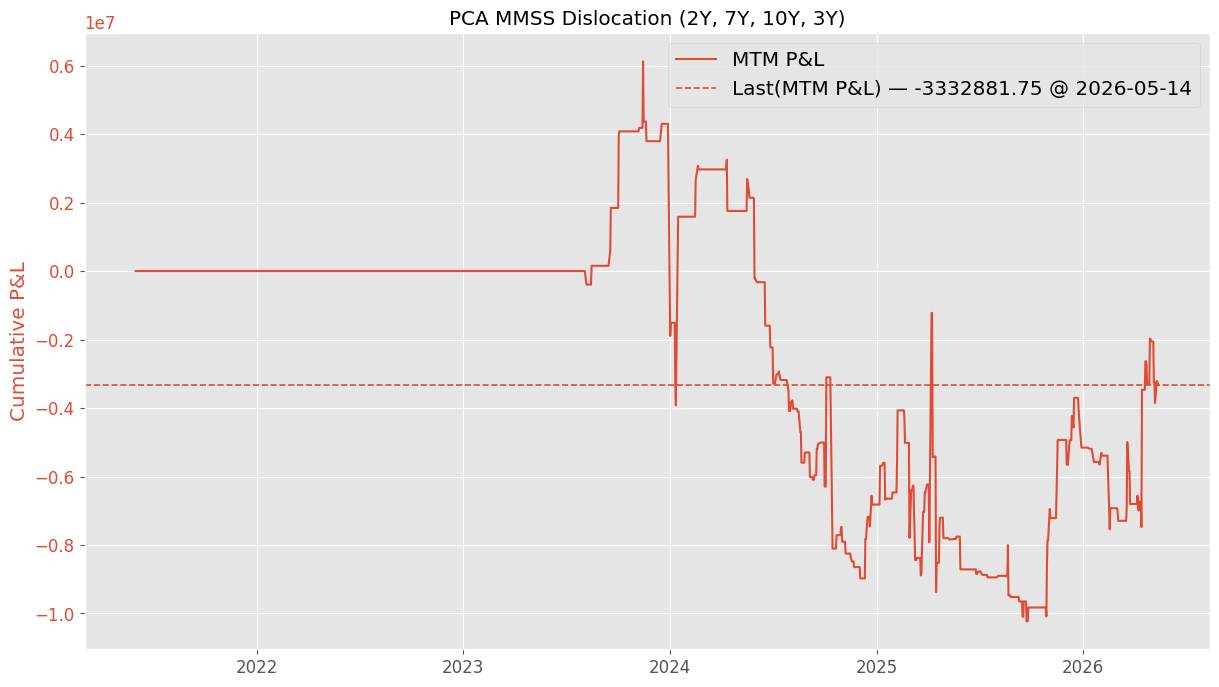

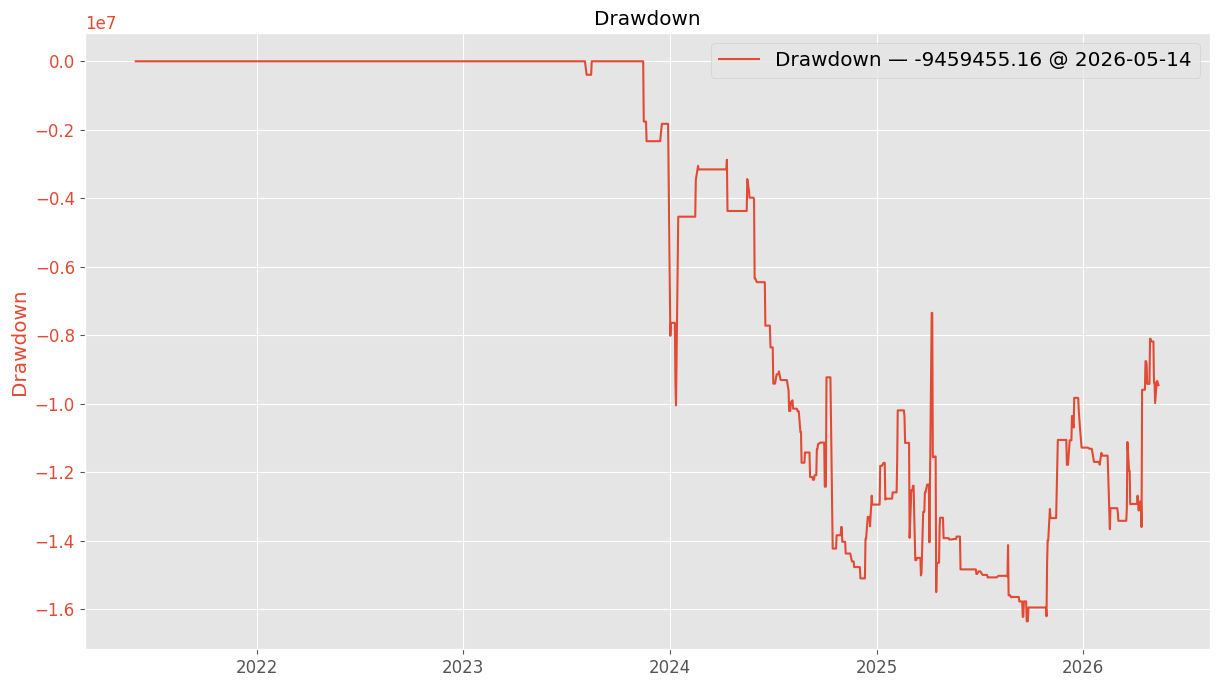

Tenors:       ['2Y', '7Y', '10Y', '3Y']
Signal:       z_entry=1.5, z_exit=0.25, max_hold=60
PCA:          3 PCs, window=520, input=changes
Risk BPV:     100,000

Final MTM:      -3,332,882
Peak:            6,126,573
Max DD:        -16,354,169
Sharpe:              -0.09
Daily vol:         479,737


In [53]:
mtm = pd.Series(bt.mtm_history).sort_index()
daily_pnl = mtm.diff().dropna()

plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Cumulative P&L', title=strategy.name,
)
plot(mtm.rename('MTM P&L'), which='left', indicators=[
    {'kind': 'last', 'style': {'linestyle': '--', 'linewidth': 1.2}},
])
legend(show_date=True)
plt.show()

# Drawdown
dd = mtm - mtm.cummax()
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Drawdown', title='Drawdown',
)
plot(dd.rename('Drawdown'), which='left')
legend(show_date=True)
plt.show()

sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0
max_dd = dd.min()

print(f'Tenors:       {TRADE_TENORS}')
print(f'Signal:       z_entry={cfg["z_entry"]}, z_exit={cfg["z_exit"]}, max_hold={cfg["max_hold"]}')
print(f'PCA:          {cfg["n_components"]} PCs, window={cfg["pca_window"]}, input={cfg["pca_input"]}')
print(f'Risk BPV:     {cfg["risk_bpv"]:,}')
print(f'\nFinal MTM:    {mtm.iloc[-1]:>12,.0f}')
print(f'Peak:         {mtm.max():>12,.0f}')
print(f'Max DD:       {max_dd:>12,.0f}')
print(f'Sharpe:       {sharpe:>12.2f}')
print(f'Daily vol:    {daily_pnl.std():>12,.0f}')

## Closed Trades Analysis

Per-trade P&L aggregated by tag (bond + swap legs summed). Tags extracted from `source_query.tags`.

In [54]:
closed = pd.DataFrame(bt.portfolio.closed_positions_log)

if not closed.empty:
    def _extract_tag(row):
        sq = row.get('source_query', None)
        if sq is not None and hasattr(sq, 'tags') and sq.tags:
            return sq.tags[0]
        pos = row.get('position', None)
        if pos is not None and hasattr(pos, 'source_query'):
            sq2 = pos.source_query
            if hasattr(sq2, 'tags') and sq2.tags:
                return sq2.tags[0]
        return None

    closed['tag'] = closed.apply(_extract_tag, axis=1)
    trade_pnl = closed.dropna(subset=['tag']).groupby('tag').agg(
        realized_pnl=('realized_pnl', 'sum'),
        holding_days=('holding_period_days', 'mean'),
        opened=('opened_at', 'min'),
        closed=('closed_at', 'max'),
    ).sort_values('opened')

    trade_pnl['tenor'] = trade_pnl.index.str.extract(r'pca-(\w+)-')[0].values

    n_trades = len(trade_pnl)
    n_winners = (trade_pnl['realized_pnl'] > 0).sum()
    avg_win = trade_pnl.loc[trade_pnl['realized_pnl'] > 0, 'realized_pnl'].mean()
    avg_loss = trade_pnl.loc[trade_pnl['realized_pnl'] <= 0, 'realized_pnl'].mean()

    print(f'Trades: {n_trades}')
    print(f'Winners: {n_winners} ({n_winners/n_trades:.0%})')
    if pd.notna(avg_win): print(f'Avg win:  {avg_win:,.0f}')
    if pd.notna(avg_loss): print(f'Avg loss: {avg_loss:,.0f}')
    print(f'Avg holding: {trade_pnl["holding_days"].mean():.0f} days')
    print(f'Total P&L: {trade_pnl["realized_pnl"].sum():,.0f}')
    print()

    tenor_summary = trade_pnl.groupby('tenor').agg(
        n_trades=('realized_pnl', 'count'),
        total_pnl=('realized_pnl', 'sum'),
        avg_pnl=('realized_pnl', 'mean'),
        hit_rate=('realized_pnl', lambda x: (x > 0).mean()),
        avg_days=('holding_days', 'mean'),
    )
    display(tenor_summary)
else:
    print('No closed trades.')

Trades: 191
Winners: 94 (49%)
Avg win:  646,332
Avg loss: -657,310
Avg holding: 2 days
Total P&L: -3,003,845



,n_trades,total_pnl,avg_pnl,hit_rate,avg_days
tenor,,,,,
10Y,53,-2.126856e+05,-4012.935253,0.490566,1.924528
2Y,30,-1.547909e+06,-51596.968566,0.600000,2.133333
3Y,50,-5.874282e+05,-11748.563984,0.380000,1.920000
7Y,58,-6.558224e+05,-11307.282905,0.534483,1.758621


## Financing Decomposition

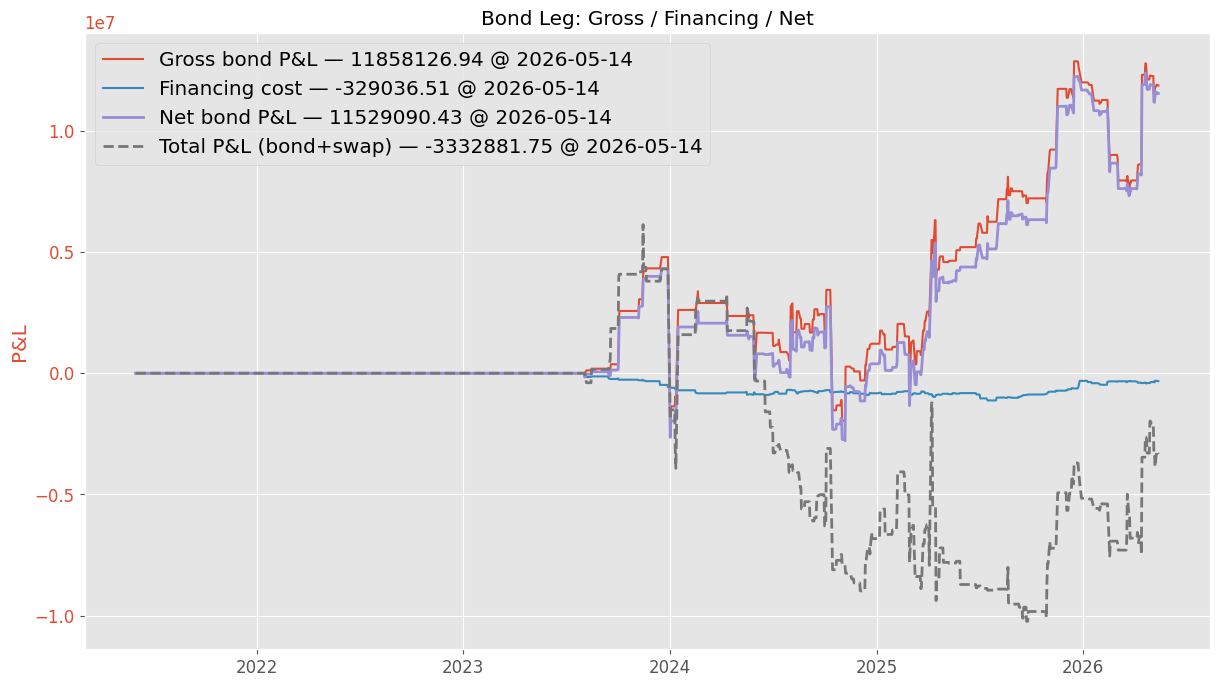

In [55]:
component_histories = getattr(bt, 'frb_component_histories', {})

if component_histories:
    time_index = pd.Index(list(tg), name='date')
    gross_bond = pd.Series(component_histories.get('bond_total', {}), dtype=float
        ).sort_index().reindex(time_index).ffill().fillna(0.0)
    financing = pd.Series(component_histories.get('financing_total', {}), dtype=float
        ).sort_index().reindex(time_index).ffill().fillna(0.0)
    net = pd.Series(component_histories.get('net_total', {}), dtype=float
        ).sort_index().reindex(time_index).ffill().fillna(0.0)

    plot, fig, ax, ax2, legend = make_secondary_axis_plot(
        ylabel_left='P&L', title='Bond Leg: Gross / Financing / Net',
    )
    plot(gross_bond.rename('Gross bond P&L'), which='left')
    plot(financing.rename('Financing cost'), which='left')
    plot(net.rename('Net bond P&L'), which='left', linewidth=2)
    plot(mtm.rename('Total P&L (bond+swap)'), which='left', linewidth=2, linestyle='--')
    legend(show_date=True)
    plt.show()
else:
    print('No FRB component history available.')

## Tearsheet

In [56]:
try:
    tearsheet = QueryBacktestTearSheet.from_backtest(bt)
    plotly_fig = tearsheet.plot_plotly()
    plotly_fig.show()
except Exception as e:
    print(f'Tearsheet: {e}')
    if len(mtm) > 1:
        daily = mtm.diff().dropna()
        sharpe = daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else 0
        max_dd = (mtm - mtm.cummax()).min()
        print(f'\nFinal P&L:  {mtm.iloc[-1]:,.0f}')
        print(f'Sharpe:     {sharpe:.2f}')
        print(f'Max DD:     {max_dd:,.0f}')